# Defining Custom Materials

SUPERMag includes a built-in database of common superconductors and
ferromagnets, but you will often need to work with custom or exotic
materials. This notebook shows how to use custom parameters directly
and how to extend the materials database.

## Built-in Materials

First, let's see what's available out of the box.

In [1]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")
import supermag
supermag.apply_theme("dark")

from supermag.materials import MATERIALS

print(f"{'Material':>15}  {'Type':>14}  {'Key parameters'}")
print("-" * 65)
for name, props in sorted(MATERIALS.items()):
    mat_type = props.get("type", "unknown")
    if mat_type == "superconductor":
        tc = props.get("Tc", "?")
        xi = props.get("xi_S", "?")
        print(f"{name:>15}  {mat_type:>14}  Tc={tc} K, ξ_S={xi} nm")
    else:
        eex = props.get("E_ex", "?")
        xi = props.get("xi_F", "?")
        print(f"{name:>15}  {mat_type:>14}  E_ex={eex} meV, ξ_F={xi} nm")

       Material            Type  Key parameters
-----------------------------------------------------------------
             Al  superconductor  Tc=1.2 K, ξ_S=1600.0 nm
             Co     ferromagnet  E_ex=309.0 meV, ξ_F=0.5 nm
   Cu0.43Ni0.57     ferromagnet  E_ex=11.2 meV, ξ_F=4.2 nm
           CuNi     ferromagnet  E_ex=5.0 meV, ξ_F=10.0 nm
             Fe     ferromagnet  E_ex=256.0 meV, ξ_F=0.7 nm
             Nb  superconductor  Tc=9.2 K, ξ_S=38.0 nm
             Ni     ferromagnet  E_ex=75.0 meV, ξ_F=2.3 nm
             Pb  superconductor  Tc=7.2 K, ξ_S=83.0 nm
             Py     ferromagnet  E_ex=20.0 meV, ξ_F=5.0 nm


## Using Custom Parameters Directly

You don't need to use the materials database at all — just pass
numerical values directly to the solver functions.

### Example: A Hypothetical Weak Ferromagnet

Consider a custom alloy with:
- $E_{\text{ex}} = 10$ meV (weak exchange)
- $\xi_F = 8$ nm (long coherence length → visible oscillations)
- Paired with a 30 nm Nb film ($T_{c0} = 9.2$ K, $\xi_S = 38$ nm)

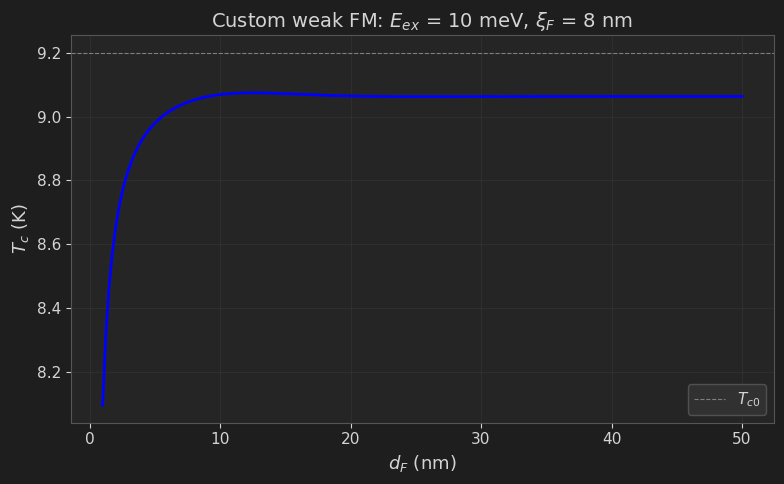

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

supermag.apply_theme("dark")

d_F = np.linspace(1, 50, 200)

Tc = supermag.critical_temperature(
    Tc0=9.2,         # K (Nb)
    d_S=30.0,        # nm
    d_F_array=d_F,
    E_ex=10.0,       # meV (weak ferromagnet)
    xi_S=38.0,       # nm
    xi_F=8.0,        # nm (long coherence length)
    gamma=0.15,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_F, Tc, 'b-', linewidth=2)
ax.axhline(9.2, ls="--", color="gray", linewidth=0.8, label=r"$T_{c0}$")
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title(r"Custom weak FM: $E_{ex}$ = 10 meV, $\xi_F$ = 8 nm", fontsize=14)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## Adding a Material to the Database

You can register custom materials at runtime so they're accessible
via `get_material()` throughout your session.

### Required Fields

**Superconductors:**

| Field | Description | Units |
|-------|-------------|-------|
| `type` | Must be `"superconductor"` | — |
| `Tc` | Critical temperature | K |
| `xi_S` | Coherence length | nm |

**Ferromagnets:**

| Field | Description | Units |
|-------|-------------|-------|
| `type` | Must be `"ferromagnet"` | — |
| `E_ex` | Exchange energy | meV |
| `xi_F` | Coherence length | nm |
| `D_F` | Diffusion constant (optional) | m²/s |

In [3]:
from supermag.materials import MATERIALS

# Register a custom ferromagnetic alloy
MATERIALS["MyAlloy"] = {
    "type": "ferromagnet",
    "E_ex": 15.0,     # meV
    "xi_F": 6.0,      # nm
    "D_F": 3.5e-4,    # m^2/s
}

# Now it works with get_material()
my_alloy = supermag.get_material("MyAlloy")
print("MyAlloy:", my_alloy)

MyAlloy: {'type': 'ferromagnet', 'E_ex': 15.0, 'xi_F': 6.0, 'D_F': 0.00035}


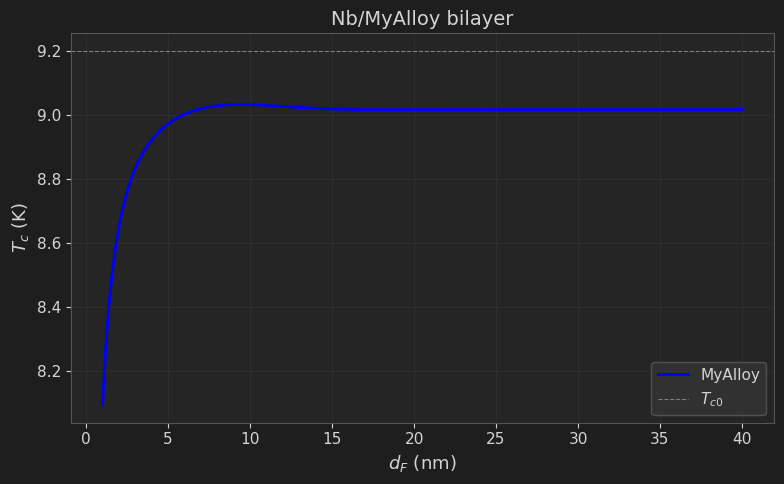

In [4]:
# Use the custom material in a calculation
nb = supermag.get_material("Nb")
ma = supermag.get_material("MyAlloy")

d_F = np.linspace(1, 40, 200)
Tc = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_F,
    E_ex=ma["E_ex"], xi_S=nb["xi_S"], xi_F=ma["xi_F"],
    gamma=0.15,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_F, Tc, 'b-', linewidth=2, label="MyAlloy")
ax.axhline(nb["Tc"], ls="--", color="gray", linewidth=0.8, label=r"$T_{c0}$")
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title("Nb/MyAlloy bilayer", fontsize=14)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## Estimating $\xi_F$ from Experimental Data

Often you know $D_F$ (from resistivity) and $E_{\text{ex}}$ (from magnetization
measurements) but not $\xi_F$ directly. The relationship is:

$$
\xi_F = \sqrt{\frac{\hbar D_F}{E_{\text{ex}}}}
$$

In practical units:

$$
\xi_F \,(\text{nm}) = \sqrt{\frac{\hbar\, D_F\,(\text{m}^2/\text{s})}
{E_{\text{ex}}\,(\text{meV}) \times 1.602 \times 10^{-22}\,(\text{J/meV})}}
\times 10^9
$$

In [ ]:
import scipy.constants as const

def estimate_xi_F(D_F_m2s, E_ex_meV):
    """Estimate ferromagnetic coherence length from D_F and E_ex."""
    E_ex_J = E_ex_meV * const.eV * 1e-3
    xi_F_m = np.sqrt(const.hbar * D_F_m2s / E_ex_J)
    return xi_F_m * 1e9  # convert to nm

# Examples
print(f"{'Material':>12}  {'D_F (m²/s)':>12}  {'E_ex (meV)':>10}  {'ξ_F (nm)':>8}")
print("-" * 50)
for name, D, E in [("CuNi", 4e-4, 11.2),
                    ("PdNi", 1e-4, 3.0),
                    ("Ni", 2e-4, 150),
                    ("Fe", 1e-4, 256)]:
    xi = estimate_xi_F(D, E)
    print(f"{name:>12}  {D:>12.1e}  {E:>10.1f}  {xi:>8.2f}")

    Material    D_F (m²/s)  E_ex (meV)  ξ_F (nm)
--------------------------------------------------
        CuNi       4.0e-04        11.2      4.85
        PdNi       1.0e-04         3.0      4.68
          Ni       2.0e-04       150.0      0.94
          Fe       1.0e-04       256.0      0.51


: 